In [113]:
import torch
import numpy as np
import matplotlib.pyplot as plt

生成Hadamard矩阵

In [114]:
def hadamard(n):
    if n == 1:
        return torch.tensor([[1.]])
    else:
        H = hadamard(n // 2)
        top = torch.cat([H, H], dim=1)
        bottom = torch.cat([H, -H], dim=1)
        return torch.cat([top, bottom], dim=0)

绘图

In [115]:
def analyze_matrix_distribution(matrix, bins=500, smooth_window=10, path=None):
    arr = np.array(matrix).flatten()
    sorted_arr = np.sort(arr)

    # 直方图统计
    hist, bin_edges = np.histogram(sorted_arr, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 包络线：滑动平均
    kernel = np.ones(smooth_window) / smooth_window
    hist_smooth = np.convolve(hist, kernel, mode="same")

    # 绘图
    plt.figure()
    plt.hist(sorted_arr, bins=bins)
    plt.plot(bin_centers, hist_smooth)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Distribution with Envelope")
    plt.show()
    
    if path is not None:
        plt.savefig(path)
        plt.close()

    return arr.mean(), arr.std()

In [116]:
def swap_rows_cols(A, i, j):
    A = A.clone()
    A[[i, j], :] = A[[j, i], :]
    A[:, [i, j]] = A[:, [j, i]]
    return A

# 多通道离群值hadamard变换结果

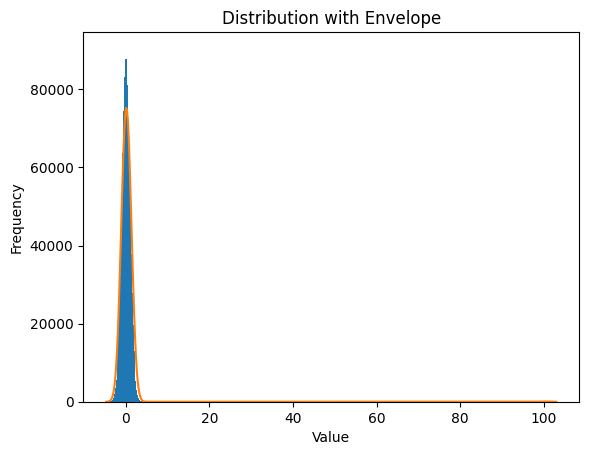

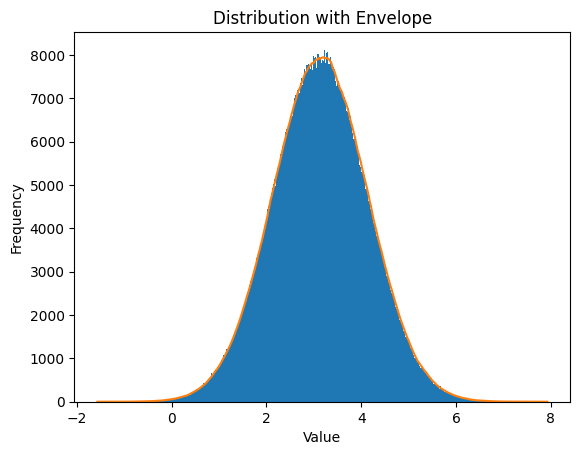

(3.1254876, 0.9993968)

In [117]:
n = 1024
A = torch.randn(n, n)
A[100, :] += 100
# A[200, :] += 120
# A[300, :] += 150
# A[400, :] += 80
# A[500, :] += 100
# A[600, :] += 120
# A[700, :] += 150
# A[800, :] += 80
# A[900, :] += 100
# A[1000, :] += 120

H = hadamard(n)
H = swap_rows_cols(H, 0, 100)
A_had = H @ A / np.sqrt(n)
analyze_matrix_distribution(A)
analyze_matrix_distribution(A_had)